In [1]:
import torch
import os
import sys
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import os
from PIL import Image
from torchvision import transforms
import torch
import numpy as np
import cv2

In [38]:
def get_dino_v2_backbone():
    # This returns a model directly, not a state_dict
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")  # ✅ this is already a model dinov2_vitb14
    return backbone

class DINOv2SegmentationModel(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        self.decoder = nn.Sequential(
            nn.Conv2d(768, 256, kernel_size=3, padding=1), #768
            nn.ReLU(),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        features = self.backbone.get_intermediate_layers(x, n=1)[0]  # (B, N, 768)
        feat_size = int(features.shape[1] ** 0.5)
        features = features.permute(0, 2, 1).reshape(B, 768, feat_size, feat_size)  # (B, 768, h, w) #768
        out = self.decoder(features)  # (B, num_classes, h, w)
        out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)  # upscale to 1022x1022
        return out

In [39]:
def make_prediction(img_path):
    transform = transforms.Compose([
        transforms.Resize((1022, 1022)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # (1, 3, 1022, 1022)
    image_np = np.array(Image.open(img_path).convert("RGB").resize((1022, 1022)))
    with torch.no_grad():
        output = model(input_tensor)  # (1, num_classes, 1022, 1022)
        pred_mask = output.argmax(dim=1).squeeze(0).cpu().numpy()  # (1022, 1022)
        
    return image_np, pred_mask

In [40]:
def compute_metrics(pred_mask, true_mask, num_classes=2):
    """
    pred_mask: torch.Tensor or np.array (H, W) — predicted class per pixel
    true_mask: torch.Tensor or np.array (H, W) — ground truth class per pixel
    """
    if isinstance(pred_mask, torch.Tensor):
        pred_mask = pred_mask.cpu().numpy()
    if isinstance(true_mask, torch.Tensor):
        true_mask = true_mask.cpu().numpy()

    ious = []
    dices = []
    pixel_acc = np.mean(pred_mask == true_mask)

    for cls_1 in range(1,num_classes):
        pred_cls = (pred_mask == cls_1)
        true_cls = (true_mask == cls_1)

        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()
        iou = intersection / union if union > 0 else np.nan

        dice = (2 * intersection) / (pred_cls.sum() + true_cls.sum()) if (pred_cls.sum() + true_cls.sum()) > 0 else np.nan

        ious.append(iou)
        dices.append(dice)

    mean_iou = np.nanmean(ious)
    mean_dice = np.nanmean(dices)

    return {
        "pixel_accuracy": pixel_acc,
        "iou_per_class": ious,
        "mean_iou": mean_iou,
        "dice_per_class": dices,
        "mean_dice": mean_dice
    }

In [41]:
path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/kif_codes/20250502225532dino_v2_segmentation.pth"

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = get_dino_v2_backbone()
model = DINOv2SegmentationModel(backbone, num_classes=4)
model.load_state_dict(torch.load(path, map_location=device))
model.to(device)
model.eval()  # 🔍 Important for inference

Using cache found in /home/mahirwar/.cache/torch/hub/facebookresearch_dinov2_main
xFormers not available
xFormers not available
/tmp/ipykernel_1092551/676118750.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues 

DINOv2SegmentationModel(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False

In [126]:
dataset_test_location =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Train_val_LB/test_corrected/"
test_folders = glob(os.path.join(dataset_test_location, "*"))

In [127]:
test_imgs_all = []
test_masks_all = []
for i in range(len(test_folders)):
    test_imgs = glob(os.path.join(test_folders[i],"image", "*"))
    test_masks = glob(os.path.join(test_folders[i],"mask", "*"))
    test_imgs_all.extend(test_imgs)
    test_masks_all.extend(test_masks)

In [128]:
test_imgs_all.sort()
test_masks_all.sort()


In [129]:
num_classes = 4

In [130]:
cv2.connectedComponents(pred_mask.astype(np.uint8))

(2,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32))

In [131]:

ids = np.unique(pred_mask)

In [132]:
ids = np.array([1,2])

In [133]:
all_masks = (pred_mask[np.newaxis] == ids[:,  np.newaxis, np.newaxis])


In [134]:
np.unique(all_masks[0])

array([False,  True])

In [137]:
metrics_all = []
classification = []
class_matches =  {"1":0,"2":0,"3":0}
total_matches = {"1":0,"2":0,"3":0}
ious = []
dices = []
counts = 0
totals = 0 

for img_path, mask_path in zip(test_imgs_all,test_masks_all):
    img, pred_mask = make_prediction(img_path)
    mask = Image.open(mask_path).convert("P").resize((1022, 1022))
    true_mask = np.array(mask)//50
    true_ids = np.unique(true_mask)
    pred_ids = np.unique(pred_mask)
    all_true_masks = (true_mask[np.newaxis] == true_ids[:,  np.newaxis, np.newaxis])
    all_pred_masks = (pred_mask[np.newaxis] == pred_ids[:,  np.newaxis, np.newaxis])
    if len(all_pred_masks[1:])>0:
        for true_cls in all_true_masks[1:]:
            for pred_cls in all_pred_masks[1:]:
                intersection = np.logical_and(pred_cls, true_cls).sum()
                print(intersection)
                union = np.logical_or(pred_cls, true_cls).sum()
                print(union)
                iou = intersection / union if union > 0 else np.nan
                if iou>=0.25:
                    dice = (2 * intersection) / (pred_cls.sum() + true_cls.sum()) if (pred_cls.sum() + true_cls.sum()) > 0 else np.nan
                    ious.append(iou)
                    dices.append(dice)
                    counts=counts+1
    totals =  totals+len(all_true_masks[1:])
                    
    
    """
    for cls_1 in range(1,num_classes):
        pred_cls = (pred_mask == cls_1)
        true_cls = (true_mask == cls_1)
        true_labels, _ = cv2.connectedComponents(true_cls.astype(np.uint8))
        pred_labels, _ = cv2.connectedComponents(pred_cls.astype(np.uint8))
        print(true_labels,pred_labels )
        if true_labels-1>0:
            intersection = np.logical_and(pred_cls, true_cls).sum()
            total_matches[str(cls_1)]=total_matches[str(cls_1)]+(true_labels-1)
            union = np.logical_or(pred_cls, true_cls).sum()
            iou = intersection / union if union > 0 else np.nan
            dice = (2 * intersection) / (pred_cls.sum() + true_cls.sum()) if (pred_cls.sum() + true_cls.sum()) > 0 else np.nan
            ious.append(iou)
            dices.append(dice)
            if intersection>0:
                class_matches[str(cls_1)]=class_matches[str(cls_1)]+max(true_labels-1,pred_labels-1)
    """

174
307
246
316
126
228
408
489
0
89
0
124
178
294
396
637
144
197
84
154
203
364
29
216
379
547
386
1024
0
432
0
383
0
477
45
451
393
564
0
970
902
1427
0
944
413
579
0
480
544
730
58
378
0
222
158
602
2
544
411
763
335
1802
1467
3606
2
2618
632
960
0
1052
366
542
0
573
0
783
132
316
912
1792
0
1277
412
781
0
1020
44
947
1510
3161
15
1192
272
871
0
360
0
366
199
301
1106
1772
1001
1539
0
1579
0
1025
0
983
479
651
0
522
1525
2203
0
1933
16
1424
657
886
0
752
890
1043
0
1030
0
1045
1081
3083
0
2975
400
1264
311
1262
0
805
0
714
842
1823
1583
2346
126
2155
0
2023
0
375
1741
3433
1440
1959
691
912
461
1505
30
345
1014
1813
2172
2947
273
2821
610
1187
0
887
0
613
377
1337
0
414
1161
2896
0
1570
129
209
2
154
819
932
0
1054
1533
2163
9
1638
0
1678
73
1378
92
631
0
1192
0
464
1140
2019
0
1479
0
2065
20
365
342
1113
223
924
74
2285
1108
1371
287
918
1413
1859
665
847
0
893
281
381
0
377
1172
1629
732
842
0
895
0
1072
139
254
182
346
311
1148
550
1476
0
1175
0
546
0
1113
0
262
573
2581
0
755
3

In [138]:
totals

172

In [139]:
np.mean(ious)

0.640285926774825

In [140]:
np.mean(dices)

0.7648740425018675

In [141]:
counts/totals

0.7906976744186046

In [28]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd

def draw_bounding_boxes(image_path, boxes, box_color=(255, 0, 0), thickness=2):
    """
    Draw bounding boxes on an image.
    
    Args:
        image_path (str): Path to the image.
        boxes (list of lists): Bounding boxes in [x1, y1, x2, y2] format.
        box_color (tuple): Color of the box in BGR (OpenCV default).
        thickness (int): Thickness of the box lines.
    
    Returns:
        image: Annotated image as NumPy array.
    """
    image = cv2.imread(image_path)
    image = cv2.resize(image, (1022,1022), interpolation=cv2.INTER_LINEAR)
    if image is None:
        raise ValueError(f"Image not found: {image_path}")
    
    for box in boxes:
        x1, y1, x2, y2 = box
        cv2.rectangle(image, (x1, y1), (x2, y2), box_color, thickness)
    
    return image

def show_image(image, title='Image with Bounding Boxes'):
    # Convert BGR to RGB for visualization
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()


In [127]:
df = pd.read_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/seg_results/2012-60-C34-45-Amygdala.svs.csv")

In [128]:
df1 = df[df["area"]>200]

In [213]:
path1 = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/prov-gigapath/data/antibodies_data/tiles/output"
row = df1.iloc[789]
img_path = os.path.join(path1, row["img_name"])
bbox_xmin = row["bbox_xmin"]
bbox_xmax = row["bbox_xmax"]
bbox_ymin = row["bbox_ymin"]
bbox_ymax = row["bbox_ymax"]
boxes = [[bbox_ymin,bbox_xmin,bbox_ymax,bbox_xmax]]

In [214]:
df["area"].quantile(0.25)

33.0

In [215]:
df["area"].quantile(0.5)

147.0

In [216]:
df["area"].quantile(0.95)

1409.0

In [217]:
boxes

[[213, 67, 238, 92]]

In [218]:
image = draw_bounding_boxes(img_path, boxes, box_color=(0, 0, 0), thickness=2)

In [219]:
img, pred_mask = make_prediction(img_path)

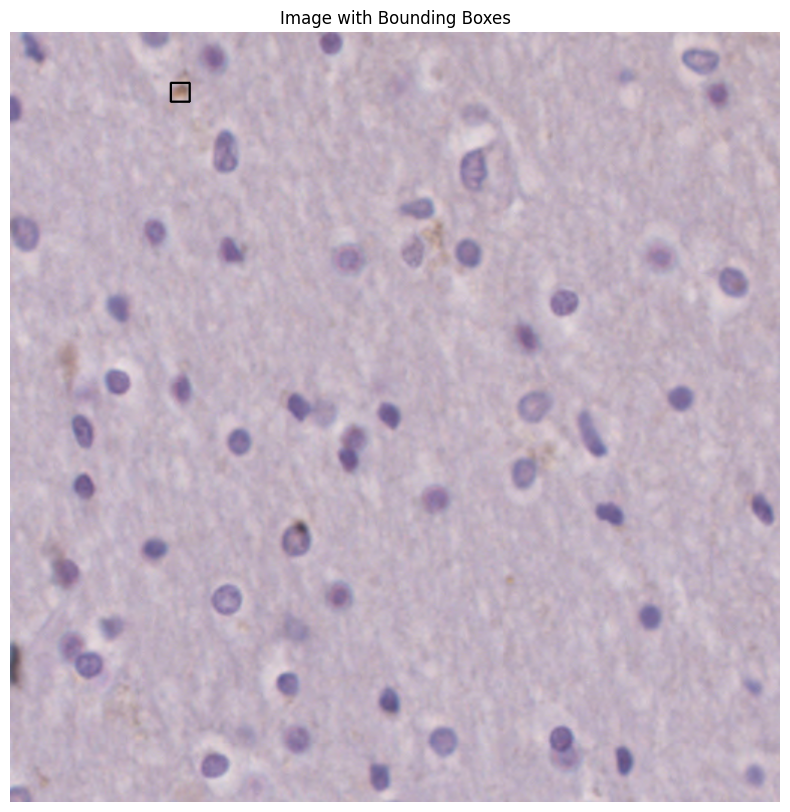

In [220]:
show_image(image, title='Image with Bounding Boxes')

In [221]:
np.unique(pred_mask)

array([0, 2])

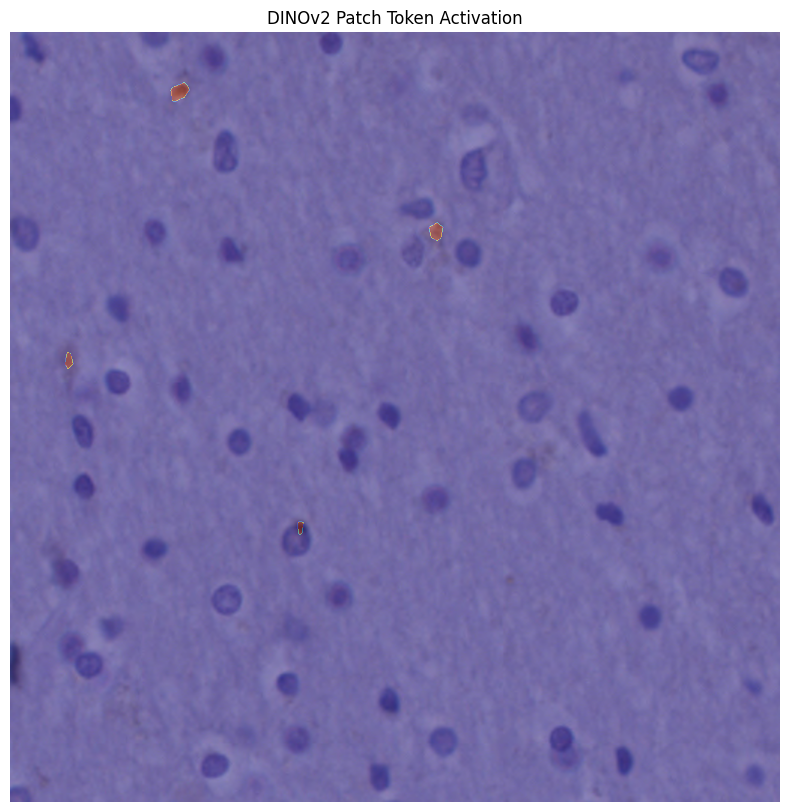

In [222]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.imshow(pred_mask, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("DINOv2 Patch Token Activation")
plt.show()

In [228]:
test_df = df[(df["area"]>200) & (df["class"]==1)]

In [229]:
test_df.columns

Index(['Unnamed: 0', 'slide_id', 'img_name', 'area', 'perimeter',
       'eccentricity', 'major_axis_length', 'minor_axis_length', 'solidity',
       'extent', 'aspect_ratio', 'circularity', 'bbox_xmin', 'bbox_xmax',
       'bbox_ymin', 'bbox_ymax', 'centroid_x', 'centroid_y', 'label', 'class'],
      dtype='object')

In [236]:
test_df["x"] =test_df["img_name"].apply(lambda l: int(l.split("/")[-1].split("x")[0]))
test_df["y"] =test_df["img_name"].apply(lambda l: int(l.split("/")[-1].split("_")[-1].split("y")[0]))

/tmp/ipykernel_1092551/2825087740.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["x"] =test_df["img_name"].apply(lambda l: int(l.split("/")[-1].split("x")[0]))
/tmp/ipykernel_1092551/2825087740.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["y"] =test_df["img_name"].apply(lambda l: int(l.split("/")[-1].split("_")[-1].split("y")[0]))


In [237]:
test_df.head(2)

,Unnamed: 0,slide_id,img_name,area,perimeter,eccentricity,major_axis_length,minor_axis_length,solidity,extent,...,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,centroid_x,centroid_y,label,class,x,y
12,12,2012-60-C34-45-Amygdala.svs,2012-60-C34-45-Amygdala.svs/62392x_01511y.png,849.0,108.911688,0.538690,35.891405,30.238665,0.960407,0.764865,...,708,745,445,475,726.274441,459.406360,1,1,62392,1511
17,17,2012-60-C34-45-Amygdala.svs,2012-60-C34-45-Amygdala.svs/64440x_01511y.png,344.0,81.248737,0.912452,33.426365,13.677536,0.927224,0.671875,...,631,647,886,918,637.837209,899.468023,1,1,64440,1511


In [243]:
test_df["bbox_xmin_new"] = test_df["x"] +test_df['bbox_xmin']
test_df["bbox_xmax_new"] = test_df["x"] +test_df['bbox_xmax']
test_df["bbox_ymin_new"] = test_df["y"] +test_df['bbox_ymin']
test_df["bbox_ymax_new"] = test_df["y"] +test_df['bbox_ymax']

/tmp/ipykernel_1092551/4152539691.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["bbox_xmin_new"] = test_df["x"] +test_df['bbox_xmin']
/tmp/ipykernel_1092551/4152539691.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["bbox_xmax_new"] = test_df["x"] +test_df['bbox_xmax']
/tmp/ipykernel_1092551/4152539691.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [244]:
test_df[["bbox_xmin_new","bbox_xmax_new","bbox_ymin_new","bbox_ymax_new"]].to_csv("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/crop_based/2012-60-C34-45-Amygdala.csv")

In [245]:
test_df.head(2)

,Unnamed: 0,slide_id,img_name,area,perimeter,eccentricity,major_axis_length,minor_axis_length,solidity,extent,...,centroid_x,centroid_y,label,class,x,y,bbox_xmin_new,bbox_xmax_new,bbox_ymin_new,bbox_ymax_new
12,12,2012-60-C34-45-Amygdala.svs,2012-60-C34-45-Amygdala.svs/62392x_01511y.png,849.0,108.911688,0.538690,35.891405,30.238665,0.960407,0.764865,...,726.274441,459.406360,1,1,62392,1511,63100,63137,1956,1986
17,17,2012-60-C34-45-Amygdala.svs,2012-60-C34-45-Amygdala.svs/64440x_01511y.png,344.0,81.248737,0.912452,33.426365,13.677536,0.927224,0.671875,...,637.837209,899.468023,1,1,64440,1511,65071,65087,2397,2429
